In [ ]:
import ase
from ase.io import read
from ase.visualize import view
from bekkers_tutorials.orthonormal_radial_basis import (
    FixedCosineRadialModel,
    CosineFunctions,
    FadeAtCutoff,
    OrthonormalRadialFunctions
    )
from bekkers_tutorials.radial_spherical_tensor import *
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
import torch.autograd.functional

torch.set_default_dtype(torch.float32)

We'll use a small molecule as an examplar. We'll store and visualize it using the ASE (Atomic Simulation Environment) library 
(J. Phys.: Condens. Matter Vol. 29 273002, 2017).

In [18]:
from ase.build import molecule
atoms = molecule('N2H4')
view(atoms, viewer='x3d')

Set up a radial-spherical tensor definition, using the Gram-Schmidt orthornormalization of some truncated and shifted cosines for the radial basis.

In [19]:
rcut = 2
lmax = 4
p_val = 1
p_arg = 1
nRadialFunctions = (lmax+1)

fixedCosineRadialModel = FixedCosineRadialModel(rcut, nRadialFunctions)
onRadialModel = OrthonormalRadialFunctions(nRadialFunctions, fixedCosineRadialModel, rcut, 1024)

rst = RadialSphericalTensor(nRadialFunctions, onRadialModel, lmax, p_val, p_arg)

We'll visualize the radial basis for your enjoyment. The first plot here is non-orthonormal, and the second is the Gram-Schmidt orthonormalization of the first.

C:\Users\Viggo\AppData\Local\Temp\ipykernel_21124\2242539327.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Viggo\AppData\Local\Temp\ipykernel_21124\2242539327.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


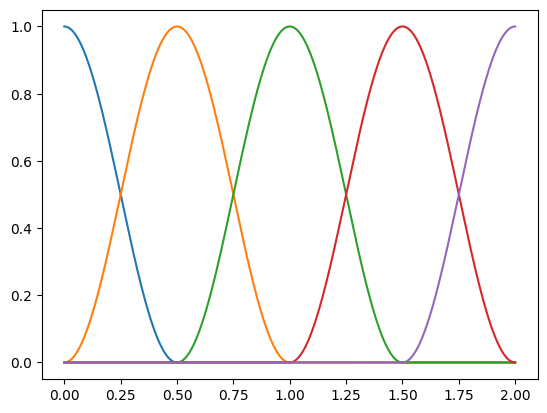

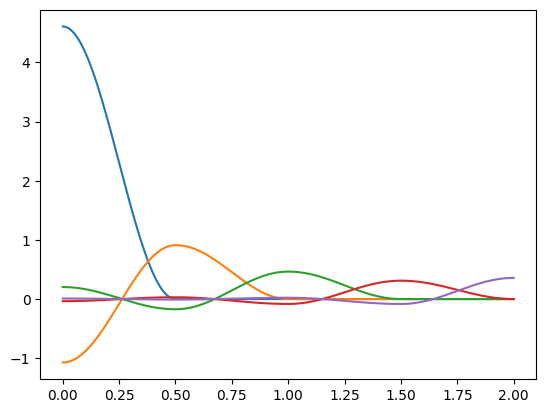

In [20]:
r = torch.linspace(0,rcut,1000)
y = fixedCosineRadialModel(r)
fig = plt.figure()
p = plt.plot(r,y)
fig.show()

r = torch.linspace(0,rcut,1000)
y = onRadialModel(r)
fig = plt.figure()
p = plt.plot(r,y)
fig.show()

Convert the exemplar molecule to a signal using the radial-spherical tensor we defined in the previous cell. We'll place peaks of height 1 on heavy atoms, and peaks of height -1 on hydrogen atoms.

In [21]:
atomValues = torch.zeros((len(atoms),))
atomValues[atoms.get_atomic_numbers()==1]=-1
atomValues[atoms.get_atomic_numbers()>1]=1
originalSignal = rst.with_peaks_at(torch.tensor(atoms.get_positions(), dtype=atomValues.dtype), atomValues)
print(originalSignal)

tensor([-1.4319e-14,  1.4594e-01, -4.8736e-02, -5.3230e-01,  1.4249e-01,
        -1.0958e-22,  2.7201e-22, -6.4970e-15,  5.4694e-24,  3.0422e-09,
        -2.7156e-02, -5.7785e-10, -1.1102e-09, -4.0020e-02,  9.5863e-09,
         8.8808e-09, -1.8268e-01,  1.6904e-09,  9.6407e-10,  4.8900e-02,
         9.6842e-23,  1.0996e-14, -7.3567e-15, -7.6926e-24,  6.1558e-16,
         2.1575e-24, -3.8542e-16,  3.2069e-01,  5.0030e-10,  3.2617e-03,
         7.2673e-10,  3.4941e-02, -2.4300e-03, -1.1766e-09, -5.6074e-03,
         2.4419e-09,  3.5846e-01, -4.0760e-01,  1.1966e-08,  2.4946e-02,
        -2.3851e-09, -9.5954e-02,  1.0911e-01, -2.7242e-09, -6.6776e-03,
         7.6387e-23, -1.4811e-14, -3.8977e-22,  3.4725e-23, -1.4740e-14,
        -2.4564e-22, -8.0173e-15, -7.5855e-24,  5.1913e-16, -5.3088e-24,
         5.1655e-09, -1.0014e-01,  2.9915e-12, -3.7848e-04, -1.1561e-11,
        -6.3709e-02, -1.3797e-09,  1.9681e-10, -9.0588e-02,  2.2985e-10,
        -3.4317e-02,  1.3587e-09, -4.6873e-01,  1.2

Now expand that signal into real-space. Compare to the molecule above. You should see positive peaks on heavy atoms, and negative peaks on hydrogen atoms.

In [22]:
samplePointsLinear, signalOnGrid = rst.signal_on_grid(
    originalSignal, rcut, 25, cropBases=True, cutoffRadiusInner=1e-6, useCache=True)
print(samplePointsLinear)

tensor([-2.0000, -1.8333, -1.6667, -1.5000, -1.3333, -1.1667, -1.0000, -0.8333,
        -0.6667, -0.5000, -0.3333, -0.1667,  0.0000,  0.1667,  0.3333,  0.5000,
         0.6667,  0.8333,  1.0000,  1.1667,  1.3333,  1.5000,  1.6667,  1.8333,
         2.0000])


Plot the signal in real space.

In [23]:
X, Y, Z = np.meshgrid(samplePointsLinear, samplePointsLinear, samplePointsLinear, indexing='ij')
layout = go.Layout(width=500, height=500,
                   margin=dict(l=0, r=0, t=10, b=0),)

traceVolumePositive = go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=signalOnGrid.flatten(),
    isomin=.75,
    isomax=1.0,
    opacity=0.25,
    surface_count=3,
    caps= dict(x_show=False, y_show=False, z_show=False),
    cmin=-1,
    cmax=1,
    )

traceVolumeNegative = go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=signalOnGrid.flatten(),
    isomin=-1.0,
    isomax=-.75,
    opacity=0.25,
    surface_count=3,
    caps= dict(x_show=False, y_show=False, z_show=False),
    cmin=-1,
    cmax=1,
    )

fig = go.Figure(data=[traceVolumePositive, traceVolumeNegative], layout=layout)
fig.show()

OK, so we've taken a molecule and converted it into a signal. That signal can be expanded into real space.

Now let's define a function that takes a signal from our RadialSphericalTensor and turns it into a rotationally invariant power spectrum. In e3nn terms, that conversion is a tensor product.

In [24]:
signalToPowerSpectrum_tensorProduct = o3.ReducedTensorProducts(
    'ij=ji', i=rst,
    filter_ir_out=list(o3.Irrep.iterator(lmax=0)))
print(signalToPowerSpectrum_tensorProduct.irreps_out)
signalToPowerSpectrum = lambda x: signalToPowerSpectrum_tensorProduct(x, x)

75x0e


So the tensor product produces many scalar values, which we know are rotationally invariant.

Now let's evaluate the power spectrum for the specific signal associated with our molecule above.

In [25]:
originalPowerSpectrum = signalToPowerSpectrum(originalSignal)
originalPowerSpectrum = originalPowerSpectrum.detach().clone()
print(originalPowerSpectrum)

tensor([ 2.0502e-28, -2.9552e-15,  9.8688e-16,  1.0779e-14, -2.8853e-15,
         2.1299e-02, -1.0059e-02, -1.0986e-01,  2.9409e-02,  2.3752e-03,
         3.6688e-02, -9.8208e-03,  2.8334e-01, -1.0726e-01,  2.0303e-02,
         2.4370e-29,  1.4406e-16,  2.1230e-16,  9.6907e-16, -2.5940e-16,
         4.2576e-04,  8.8734e-04,  4.0505e-03, -1.0842e-03,  9.2467e-04,
         5.9692e-03, -1.5979e-03,  1.9267e-02, -7.2938e-03,  1.3806e-03,
         7.8449e-29, -1.4908e-15,  2.5212e-16,  4.3991e-15, -1.1776e-15,
         4.5996e-02, -5.0442e-04, -8.2617e-02,  2.2115e-02,  5.6269e-04,
         8.4594e-03, -2.2644e-03,  1.3204e-01, -4.9985e-02,  9.4613e-03,
         1.8933e-28,  7.9064e-16,  1.3652e-15,  7.9229e-15, -2.1208e-15,
         3.7904e-03,  4.8559e-03,  2.1281e-02, -5.6966e-03,  5.0808e-03,
         3.9820e-02, -1.0659e-02,  1.6682e-01, -6.3151e-02,  1.1953e-02,
         2.6703e-28,  4.6544e-15,  2.1290e-15,  9.3462e-15, -2.5018e-15,
         5.6899e-02,  2.8129e-02,  1.0278e-01, -2.7

Now, let's generate a perturbed configuration of the molecule and see if we can recover it using optimization.

In [26]:
originalPositions = torch.tensor(atoms.get_positions(), dtype=torch.float32)
perturbation = 0.25 * (2*torch.rand(originalPositions.shape) - 1.0)
perturbedPositions = originalPositions + perturbation

Set up an optimization problem. We're going to try to drive from perturbedPositions back to originalPositions by minimizing the difference in power spectra.

In [27]:
candidatePositions = perturbedPositions.clone().detach()
candidatePositions.requires_grad = True
loss_fn = torch.nn.MSELoss()
optimiser = torch.optim.Adam([candidatePositions], lr=.01)

def objectiveFunction(candidatePos):
    candidateSignal = rst.with_peaks_at(candidatePos, atomValues)
    candidatePowerSpectrum = signalToPowerSpectrum(candidateSignal)
    loss = loss_fn(originalPowerSpectrum, candidatePowerSpectrum)
    return loss

Aaaaaand optimize away.

In [28]:
for iteration in range(1000):
    def closure():
        optimiser.zero_grad()
        loss = objectiveFunction(candidatePositions)
        loss.backward()
        if iteration%10==0: print(loss)
        return loss

    optimiser.step(closure)

tensor(0.0010, grad_fn=<MseLossBackward0>)
tensor(0.0004, grad_fn=<MseLossBackward0>)
tensor(0.0003, grad_fn=<MseLossBackward0>)
tensor(5.5167e-05, grad_fn=<MseLossBackward0>)
tensor(2.7330e-05, grad_fn=<MseLossBackward0>)
tensor(6.9660e-06, grad_fn=<MseLossBackward0>)
tensor(3.6289e-06, grad_fn=<MseLossBackward0>)
tensor(2.4223e-06, grad_fn=<MseLossBackward0>)
tensor(1.4710e-06, grad_fn=<MseLossBackward0>)
tensor(1.2417e-06, grad_fn=<MseLossBackward0>)
tensor(1.1132e-06, grad_fn=<MseLossBackward0>)
tensor(9.9383e-07, grad_fn=<MseLossBackward0>)
tensor(9.1377e-07, grad_fn=<MseLossBackward0>)
tensor(8.5067e-07, grad_fn=<MseLossBackward0>)
tensor(7.9485e-07, grad_fn=<MseLossBackward0>)
tensor(7.4682e-07, grad_fn=<MseLossBackward0>)
tensor(7.0452e-07, grad_fn=<MseLossBackward0>)
tensor(6.6704e-07, grad_fn=<MseLossBackward0>)
tensor(6.3371e-07, grad_fn=<MseLossBackward0>)
tensor(6.0397e-07, grad_fn=<MseLossBackward0>)
tensor(5.7738e-07, grad_fn=<MseLossBackward0>)
tensor(5.5358e-07, grad_f

Well that seemed to go well. Let's rotate our candidatePositions in an attempt to line it up with the originalPositions.

In [29]:
originalU,_,_ = torch.svd(torch.transpose(originalPositions,0,1))
_,candidateS,candidateV = torch.svd(torch.transpose(candidatePositions,0,1))
candidatePositionsRegistered = torch.transpose(torch.matmul(torch.matmul(originalU, torch.diag_embed(candidateS)), candidateV.transpose(-2, -1)),0,1)

In [30]:
candidateSignal = rst.with_peaks_at(candidatePositions, atomValues)
candidatePowerSpectrum = signalToPowerSpectrum(candidateSignal)

In [31]:
layout = go.Layout(width=500, height=500,
                   margin=dict(l=0, r=0, t=10, b=0),)

traceOriginal = go.Scatter3d(
    x=originalPositions[:,0],
    y=originalPositions[:,1],
    z=originalPositions[:,2],
    mode='markers',
    marker=dict(size=5,color=atomValues),
    )

candidatePositions = candidatePositions.detach().clone()
traceCandidate = go.Scatter3d(
    x=candidatePositions[:,0],
    y=candidatePositions[:,1],
    z=candidatePositions[:,2],
    mode='markers',
    marker=dict(size=10,color=atomValues),
    )

fig = go.Figure(data=[traceOriginal, traceCandidate], layout=layout)
fig.show()

Interesting, these two configurations are not as close as we might have hoped. We seem to have recovered a separate configuration that has the same power spectrum as our original molecule.

Let's take a look at the Hessian of the objective function. Now, we know that at originalPositions, the objective function and its gradient are zero, so the null space of the Hessian tells us about the "shape" of the minimum/minimal manifold. We expect the Hessian to have at least three null singular values, corresponding to orientational degrees of freedom; that is, because the power spectrum is rotationally invariant, there is a manifold of configurations related to each other by rotations that have the same power spectrum.

In [32]:
hessian = torch.autograd.functional.hessian(objectiveFunction, originalPositions)
hessianFlat = hessian.view(3*len(atoms),3*len(atoms))
_,S,_ = torch.svd(hessianFlat)
nullity = torch.sum((S/torch.max(S)) < 1e-6).item()
print(nullity)

10


Wow, that's a lot more than three. So there is a ten-dimensional manifold of configurations that have the same power spectrum as our molecule above. This is the reason why we don't often use the power spectrum as an invariant descriptor-- many configurations map to the same power spectrum!

In [33]:
candidatePositions

tensor([[-0.0266,  0.7177, -0.0208],
        [ 0.0355, -0.7151, -0.1332],
        [ 0.2121,  1.0393,  0.9141],
        [-1.1064,  1.0514, -0.2161],
        [-0.1147, -1.1633,  0.7693],
        [ 0.9535, -0.9247, -0.3910]])